In [2]:
import duckdb as dd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
link = []
external = []
other = []
years = []
time = []
year_months = [('2024', '01'), ('2024', '02'), ('2024', '03'), ('2024', '04'), ('2024', '05'), ('2024', '06'),
               ('2024', '07'), ('2024', '08'), ('2024', '09'), ('2024', '10'), ('2024', '11'), ('2024', '12'),
               ('2025', '01'), ('2025', '02'), ('2025', '03'), ('2025', '04'), ('2025', '05'), ('2025', '06'), 
               ('2025', '07'), ('2025', '08'), ('2025', '09'), ('2025', '10')]

for (year, month) in year_months:
    df = dd.sql(
        f"""
        SELECT 
            SUM(n) FILTER (WHERE type = 'link') AS link_n,
            SUM(n) FILTER (WHERE type = 'external') AS external_n,
            SUM(n) FILTER (WHERE type = 'other') AS other_n,
        FROM './clickstream-enwiki-{year}-{month}.parquet'
        """).df()
    
    link.append(df['link_n'].values[0])
    external.append(df['external_n'].values[0])
    other.append(df['other_n'].values[0])
    years.append(int(year))
    time.append(int(year) * 12 + int(month) - 1)

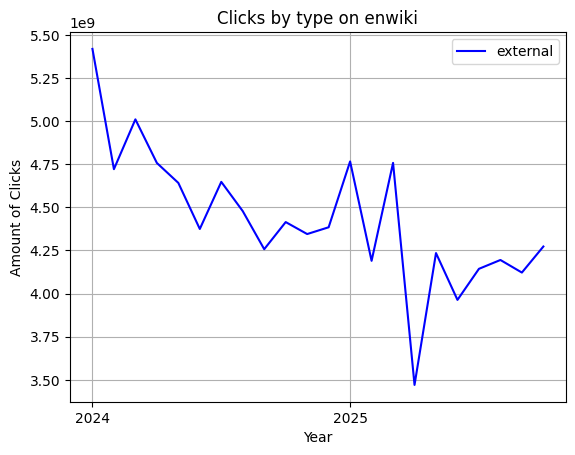

In [8]:
plt.plot(time, external, 'b-', label='external')

ticks = [2024 * 12, 2025 * 12]
labels = ['2024', '2025']

plt.xticks(ticks, labels)
plt.grid()
plt.xlabel("Year")
plt.ylabel('Amount of Clicks')
plt.title('Clicks by type on enwiki')
plt.legend()
plt.show()

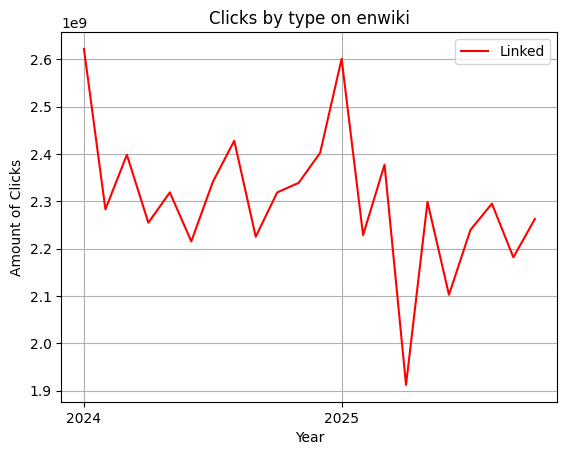

In [7]:
plt.plot(time, link, 'r-', label='Linked')

ticks = [2024 * 12, 2025 * 12]
labels = ['2024', '2025']

plt.xticks(ticks, labels)
plt.grid()
plt.xlabel("Year")
plt.ylabel('Amount of Clicks')
plt.title('Clicks by type on enwiki')
plt.legend()
plt.show()

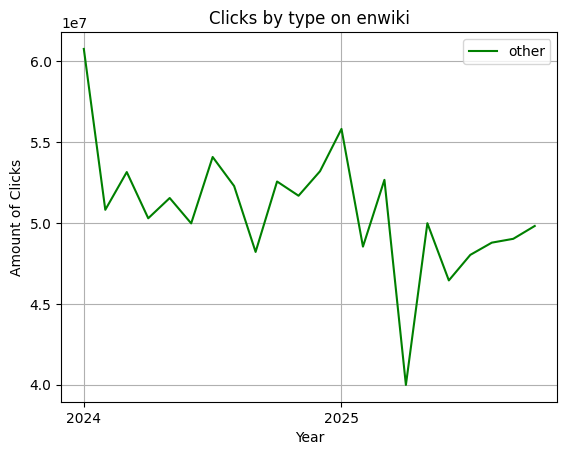

In [ ]:
plt.plot(time, other, 'g-', label='other')

ticks = [2024 * 12, 2025 * 12]
labels = ['2024', '2025']

plt.xticks(ticks, labels)
plt.grid()
plt.xlabel("Year")
plt.ylabel('Amount of Clicks')
plt.title('Clicks by type on enwiki')
plt.legend()
plt.show()

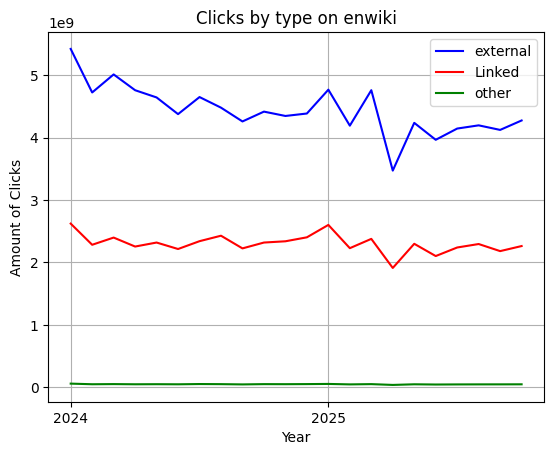

In [9]:
plt.plot(time, external, 'b-', label='external')
plt.plot(time, link, 'r-', label='Linked')
plt.plot(time, other, 'g-', label='other')

ticks = [2024 * 12, 2025 * 12]
labels = ['2024', '2025']

plt.xticks(ticks, labels)
plt.grid()
plt.xlabel("Year")
plt.ylabel('Amount of Clicks')
plt.title('Clicks by type on enwiki')
plt.legend()
plt.show()